This notebook is for testing a cell type specific linear model. The goals of this is to establish a baseline for which we can later improve upon using nonlinear methods.

Additionally, this will nicely lower bound the future analysis, as well as epigenomic regulation of transcription. 

# Imports

In [1]:
import os
import sys
import time
import warnings

PARENT_DIR = os.path.dirname(os.path.realpath(os.getcwd()))
sys.path.append(PARENT_DIR)

from tqdm import tqdm
from pathlib import Path
import pickle
import json 
import gc

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

from ak_data_loader import load_data, get_balanced_data, normalize_features

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.metrics import mutual_info_score, confusion_matrix

from scipy.stats import entropy
from itertools import combinations, cycle

### Feature List

#### All

In [3]:
# V3
META_FEATURES = ['gene_length'] #, 'gene_type', 'gene_chr']

ENHANCER_DMR_FEATURES = ['9mo.2mo.activity.log_ratio.mean.0-5kb','9mo.2mo.activity.log_ratio.median.0-5kb','9mo.2mo.activity.log_ratio.std.0-5kb','9mo.2mo.activity.log_ratio.max.0-5kb',
                         '9mo.2mo.activity.log_ratio.min.0-5kb','9mo.2mo.activity.log_ratio.count.0-5kb','18mo.2mo.activity.log_ratio.mean.0-5kb','18mo.2mo.activity.log_ratio.median.0-5kb',
                         '18mo.2mo.activity.log_ratio.std.0-5kb','18mo.2mo.activity.log_ratio.max.0-5kb','18mo.2mo.activity.log_ratio.min.0-5kb','18mo.2mo.activity.log_ratio.count.0-5kb',
                         '18mo.9mo.activity.log_ratio.mean.0-5kb','18mo.9mo.activity.log_ratio.median.0-5kb','18mo.9mo.activity.log_ratio.std.0-5kb','18mo.9mo.activity.log_ratio.max.0-5kb',
                         '18mo.9mo.activity.log_ratio.min.0-5kb','18mo.9mo.activity.log_ratio.count.0-5kb','9mo.2mo.contact.log_ratio.mean.0-5kb','9mo.2mo.contact.log_ratio.median.0-5kb',
                         '9mo.2mo.contact.log_ratio.std.0-5kb','9mo.2mo.contact.log_ratio.max.0-5kb','9mo.2mo.contact.log_ratio.min.0-5kb','9mo.2mo.contact.log_ratio.count.0-5kb',
                         '18mo.2mo.contact.log_ratio.mean.0-5kb','18mo.2mo.contact.log_ratio.median.0-5kb','18mo.2mo.contact.log_ratio.std.0-5kb','18mo.2mo.contact.log_ratio.max.0-5kb',
                         '18mo.2mo.contact.log_ratio.min.0-5kb','18mo.2mo.contact.log_ratio.count.0-5kb','18mo.9mo.contact.log_ratio.mean.0-5kb','18mo.9mo.contact.log_ratio.median.0-5kb',
                         '18mo.9mo.contact.log_ratio.std.0-5kb','18mo.9mo.contact.log_ratio.max.0-5kb','18mo.9mo.contact.log_ratio.min.0-5kb','18mo.9mo.contact.log_ratio.count.0-5kb',
                         '9mo.2mo.activity.log_ratio.mean.5kb-20kb','9mo.2mo.activity.log_ratio.median.5kb-20kb','9mo.2mo.activity.log_ratio.std.5kb-20kb','9mo.2mo.activity.log_ratio.max.5kb-20kb',
                         '9mo.2mo.activity.log_ratio.min.5kb-20kb','9mo.2mo.activity.log_ratio.count.5kb-20kb','18mo.2mo.activity.log_ratio.mean.5kb-20kb','18mo.2mo.activity.log_ratio.median.5kb-20kb',
                         '18mo.2mo.activity.log_ratio.std.5kb-20kb','18mo.2mo.activity.log_ratio.max.5kb-20kb','18mo.2mo.activity.log_ratio.min.5kb-20kb','18mo.2mo.activity.log_ratio.count.5kb-20kb',
                         '18mo.9mo.activity.log_ratio.mean.5kb-20kb','18mo.9mo.activity.log_ratio.median.5kb-20kb','18mo.9mo.activity.log_ratio.std.5kb-20kb','18mo.9mo.activity.log_ratio.max.5kb-20kb',
                         '18mo.9mo.activity.log_ratio.min.5kb-20kb','18mo.9mo.activity.log_ratio.count.5kb-20kb','9mo.2mo.contact.log_ratio.mean.5kb-20kb','9mo.2mo.contact.log_ratio.median.5kb-20kb',
                         '9mo.2mo.contact.log_ratio.std.5kb-20kb','9mo.2mo.contact.log_ratio.max.5kb-20kb','9mo.2mo.contact.log_ratio.min.5kb-20kb','9mo.2mo.contact.log_ratio.count.5kb-20kb',
                         '18mo.2mo.contact.log_ratio.mean.5kb-20kb','18mo.2mo.contact.log_ratio.median.5kb-20kb','18mo.2mo.contact.log_ratio.std.5kb-20kb','18mo.2mo.contact.log_ratio.max.5kb-20kb',
                         '18mo.2mo.contact.log_ratio.min.5kb-20kb','18mo.2mo.contact.log_ratio.count.5kb-20kb','18mo.9mo.contact.log_ratio.mean.5kb-20kb','18mo.9mo.contact.log_ratio.median.5kb-20kb',
                         '18mo.9mo.contact.log_ratio.std.5kb-20kb','18mo.9mo.contact.log_ratio.max.5kb-20kb','18mo.9mo.contact.log_ratio.min.5kb-20kb','18mo.9mo.contact.log_ratio.count.5kb-20kb',
                         '9mo.2mo.activity.log_ratio.mean.20kb-5Mb','9mo.2mo.activity.log_ratio.median.20kb-5Mb','9mo.2mo.activity.log_ratio.std.20kb-5Mb','9mo.2mo.activity.log_ratio.max.20kb-5Mb',
                         '9mo.2mo.activity.log_ratio.min.20kb-5Mb','9mo.2mo.activity.log_ratio.count.20kb-5Mb','18mo.2mo.activity.log_ratio.mean.20kb-5Mb','18mo.2mo.activity.log_ratio.median.20kb-5Mb',
                         '18mo.2mo.activity.log_ratio.std.20kb-5Mb','18mo.2mo.activity.log_ratio.max.20kb-5Mb','18mo.2mo.activity.log_ratio.min.20kb-5Mb','18mo.2mo.activity.log_ratio.count.20kb-5Mb',
                         '18mo.9mo.activity.log_ratio.mean.20kb-5Mb','18mo.9mo.activity.log_ratio.median.20kb-5Mb','18mo.9mo.activity.log_ratio.std.20kb-5Mb','18mo.9mo.activity.log_ratio.max.20kb-5Mb',
                         '18mo.9mo.activity.log_ratio.min.20kb-5Mb','18mo.9mo.activity.log_ratio.count.20kb-5Mb','9mo.2mo.contact.log_ratio.mean.20kb-5Mb','9mo.2mo.contact.log_ratio.median.20kb-5Mb',
                         '9mo.2mo.contact.log_ratio.std.20kb-5Mb','9mo.2mo.contact.log_ratio.max.20kb-5Mb','9mo.2mo.contact.log_ratio.min.20kb-5Mb','9mo.2mo.contact.log_ratio.count.20kb-5Mb',
                         '18mo.2mo.contact.log_ratio.mean.20kb-5Mb','18mo.2mo.contact.log_ratio.median.20kb-5Mb','18mo.2mo.contact.log_ratio.std.20kb-5Mb','18mo.2mo.contact.log_ratio.max.20kb-5Mb',
                         '18mo.2mo.contact.log_ratio.min.20kb-5Mb','18mo.2mo.contact.log_ratio.count.20kb-5Mb','18mo.9mo.contact.log_ratio.mean.20kb-5Mb','18mo.9mo.contact.log_ratio.median.20kb-5Mb',
                         '18mo.9mo.contact.log_ratio.std.20kb-5Mb','18mo.9mo.contact.log_ratio.max.20kb-5Mb','18mo.9mo.contact.log_ratio.min.20kb-5Mb','18mo.9mo.contact.log_ratio.count.20kb-5Mb','count',]

ENHANCER_PEAK_FEATURES = ['9mo.2mo.activity.log_ratio.mean.0-5kb','9mo.2mo.activity.log_ratio.median.0-5kb','9mo.2mo.activity.log_ratio.std.0-5kb','9mo.2mo.activity.log_ratio.max.0-5kb',
                         '9mo.2mo.activity.log_ratio.min.0-5kb','9mo.2mo.activity.log_ratio.count.0-5kb','18mo.2mo.activity.log_ratio.mean.0-5kb','18mo.2mo.activity.log_ratio.median.0-5kb',
                         '18mo.2mo.activity.log_ratio.std.0-5kb','18mo.2mo.activity.log_ratio.max.0-5kb','18mo.2mo.activity.log_ratio.min.0-5kb','18mo.2mo.activity.log_ratio.count.0-5kb',
                         '18mo.9mo.activity.log_ratio.mean.0-5kb','18mo.9mo.activity.log_ratio.median.0-5kb','18mo.9mo.activity.log_ratio.std.0-5kb','18mo.9mo.activity.log_ratio.max.0-5kb',
                         '18mo.9mo.activity.log_ratio.min.0-5kb','18mo.9mo.activity.log_ratio.count.0-5kb','9mo.2mo.contact.log_ratio.mean.0-5kb','9mo.2mo.contact.log_ratio.median.0-5kb',
                         '9mo.2mo.contact.log_ratio.std.0-5kb','9mo.2mo.contact.log_ratio.max.0-5kb','9mo.2mo.contact.log_ratio.min.0-5kb','9mo.2mo.contact.log_ratio.count.0-5kb',
                         '18mo.2mo.contact.log_ratio.mean.0-5kb','18mo.2mo.contact.log_ratio.median.0-5kb','18mo.2mo.contact.log_ratio.std.0-5kb','18mo.2mo.contact.log_ratio.max.0-5kb',
                         '18mo.2mo.contact.log_ratio.min.0-5kb','18mo.2mo.contact.log_ratio.count.0-5kb','18mo.9mo.contact.log_ratio.mean.0-5kb','18mo.9mo.contact.log_ratio.median.0-5kb',
                         '18mo.9mo.contact.log_ratio.std.0-5kb','18mo.9mo.contact.log_ratio.max.0-5kb','18mo.9mo.contact.log_ratio.min.0-5kb','18mo.9mo.contact.log_ratio.count.0-5kb',
                         '9mo.2mo.activity.log_ratio.mean.5kb-20kb','9mo.2mo.activity.log_ratio.median.5kb-20kb','9mo.2mo.activity.log_ratio.std.5kb-20kb','9mo.2mo.activity.log_ratio.max.5kb-20kb',
                         '9mo.2mo.activity.log_ratio.min.5kb-20kb','9mo.2mo.activity.log_ratio.count.5kb-20kb','18mo.2mo.activity.log_ratio.mean.5kb-20kb','18mo.2mo.activity.log_ratio.median.5kb-20kb',
                         '18mo.2mo.activity.log_ratio.std.5kb-20kb','18mo.2mo.activity.log_ratio.max.5kb-20kb','18mo.2mo.activity.log_ratio.min.5kb-20kb','18mo.2mo.activity.log_ratio.count.5kb-20kb',
                         '18mo.9mo.activity.log_ratio.mean.5kb-20kb','18mo.9mo.activity.log_ratio.median.5kb-20kb','18mo.9mo.activity.log_ratio.std.5kb-20kb','18mo.9mo.activity.log_ratio.max.5kb-20kb',
                         '18mo.9mo.activity.log_ratio.min.5kb-20kb','18mo.9mo.activity.log_ratio.count.5kb-20kb','9mo.2mo.contact.log_ratio.mean.5kb-20kb','9mo.2mo.contact.log_ratio.median.5kb-20kb',
                         '9mo.2mo.contact.log_ratio.std.5kb-20kb','9mo.2mo.contact.log_ratio.max.5kb-20kb','9mo.2mo.contact.log_ratio.min.5kb-20kb','9mo.2mo.contact.log_ratio.count.5kb-20kb',
                         '18mo.2mo.contact.log_ratio.mean.5kb-20kb','18mo.2mo.contact.log_ratio.median.5kb-20kb','18mo.2mo.contact.log_ratio.std.5kb-20kb','18mo.2mo.contact.log_ratio.max.5kb-20kb',
                         '18mo.2mo.contact.log_ratio.min.5kb-20kb','18mo.2mo.contact.log_ratio.count.5kb-20kb','18mo.9mo.contact.log_ratio.mean.5kb-20kb','18mo.9mo.contact.log_ratio.median.5kb-20kb',
                         '18mo.9mo.contact.log_ratio.std.5kb-20kb','18mo.9mo.contact.log_ratio.max.5kb-20kb','18mo.9mo.contact.log_ratio.min.5kb-20kb','18mo.9mo.contact.log_ratio.count.5kb-20kb',
                         '9mo.2mo.activity.log_ratio.mean.20kb-5Mb','9mo.2mo.activity.log_ratio.median.20kb-5Mb','9mo.2mo.activity.log_ratio.std.20kb-5Mb','9mo.2mo.activity.log_ratio.max.20kb-5Mb',
                         '9mo.2mo.activity.log_ratio.min.20kb-5Mb','9mo.2mo.activity.log_ratio.count.20kb-5Mb','18mo.2mo.activity.log_ratio.mean.20kb-5Mb','18mo.2mo.activity.log_ratio.median.20kb-5Mb',
                         '18mo.2mo.activity.log_ratio.std.20kb-5Mb','18mo.2mo.activity.log_ratio.max.20kb-5Mb','18mo.2mo.activity.log_ratio.min.20kb-5Mb','18mo.2mo.activity.log_ratio.count.20kb-5Mb',
                         '18mo.9mo.activity.log_ratio.mean.20kb-5Mb','18mo.9mo.activity.log_ratio.median.20kb-5Mb','18mo.9mo.activity.log_ratio.std.20kb-5Mb','18mo.9mo.activity.log_ratio.max.20kb-5Mb',
                         '18mo.9mo.activity.log_ratio.min.20kb-5Mb','18mo.9mo.activity.log_ratio.count.20kb-5Mb','9mo.2mo.contact.log_ratio.mean.20kb-5Mb','9mo.2mo.contact.log_ratio.median.20kb-5Mb',
                         '9mo.2mo.contact.log_ratio.std.20kb-5Mb','9mo.2mo.contact.log_ratio.max.20kb-5Mb','9mo.2mo.contact.log_ratio.min.20kb-5Mb','9mo.2mo.contact.log_ratio.count.20kb-5Mb',
                         '18mo.2mo.contact.log_ratio.mean.20kb-5Mb','18mo.2mo.contact.log_ratio.median.20kb-5Mb','18mo.2mo.contact.log_ratio.std.20kb-5Mb','18mo.2mo.contact.log_ratio.max.20kb-5Mb',
                         '18mo.2mo.contact.log_ratio.min.20kb-5Mb','18mo.2mo.contact.log_ratio.count.20kb-5Mb','18mo.9mo.contact.log_ratio.mean.20kb-5Mb','18mo.9mo.contact.log_ratio.median.20kb-5Mb',
                         '18mo.9mo.contact.log_ratio.std.20kb-5Mb','18mo.9mo.contact.log_ratio.max.20kb-5Mb','18mo.9mo.contact.log_ratio.min.20kb-5Mb','18mo.9mo.contact.log_ratio.count.20kb-5Mb','count',]

DMR_FEATURES = ['size.log2', 'rel_pos', '9mo.2mo.log_ratio', '18mo.9mo.log_ratio', '18mo.2mo.log_ratio', 'distance.log2', 'count']
DAR_FEATURES = ['rel_pos', '9mo.2mo.log_ratio', '18mo.9mo.log_ratio','18mo.2mo.log_ratio', 'count']

GENEBODY_MCG_FEATURES = ['9mo.2mo.log_ratio', '18mo.9mo.log_ratio', '18mo.2mo.log_ratio']
GENEBODY_MCH_FEATURES = ['9mo.2mo.log_ratio', '18mo.9mo.log_ratio', '18mo.2mo.log_ratio']

ATAC_FEATURES = ['9mo.2mo.log_ratio.mean', '18mo.9mo.log_ratio.mean','18mo.2mo.log_ratio.mean', 'log2_distance.mean',
                 '9mo.2mo.log_ratio.std', '18mo.9mo.log_ratio.std','18mo.2mo.log_ratio.std', 'log2_distance.std', '9mo.2mo.log_ratio.max',
                 '18mo.9mo.log_ratio.max', '18mo.2mo.log_ratio.max', 'log2_distance.max','9mo.2mo.log_ratio.min', '18mo.9mo.log_ratio.min',
                 '18mo.2mo.log_ratio.min', 'log2_distance.min', 'count']

LOOP_FEATURES = ['Qanova.mean', 'Qanova.median', 'Qanova.std', 'Qanova.max','Qanova.min', 'Tanova.mean', 'Tanova.median', 'Tanova.std',
                 'Tanova.max', 'Tanova.min', '9mo.2mo.Q.mean', '9mo.2mo.Q.median','9mo.2mo.Q.std', '9mo.2mo.Q.max', '9mo.2mo.Q.min', '18mo.9mo.Q.mean',
                 '18mo.9mo.Q.median', '18mo.9mo.Q.std', '18mo.9mo.Q.max','18mo.9mo.Q.min', '18mo.2mo.Q.mean', '18mo.2mo.Q.median',
                 '18mo.2mo.Q.std', '18mo.2mo.Q.max', '18mo.2mo.Q.min', '9mo.2mo.T.mean','9mo.2mo.T.median', '9mo.2mo.T.std', '9mo.2mo.T.max', '9mo.2mo.T.min',
                 '18mo.9mo.T.mean', '18mo.9mo.T.median', '18mo.9mo.T.std','18mo.9mo.T.max', '18mo.9mo.T.min', '18mo.2mo.T.mean',
                 '18mo.2mo.T.median', '18mo.2mo.T.std', '18mo.2mo.T.max','18mo.2mo.T.min', 'loop_size.log.mean', 'loop_size.log.median',
                 'loop_size.log.std', 'loop_size.log.max', 'loop_size.log.min','min_distance.log.mean', 'min_distance.log.median',
                 'min_distance.log.std', 'min_distance.log.max', 'min_distance.log.min','count']

DATA_FEATURE_NAMES = {'meta' : META_FEATURES,
                      'enhancer_DMR' : ENHANCER_DMR_FEATURES,
                      'enhancer_peak' : ENHANCER_DMR_FEATURES,
                      'DAR' : DAR_FEATURES, 
                      'DMR' : DMR_FEATURES,
                      'loops' : LOOP_FEATURES,
                      'mcg_genebody' : GENEBODY_MCG_FEATURES, 
                      'mch_genebody' : GENEBODY_MCH_FEATURES, 
                      'atac' : ATAC_FEATURES}

### Only 2mo and 18mo

# Functions

In [4]:
def load_data_wrapper(ct, DATA_FEATURE_NAMES, y_val:str = "DEG", _testing_type:str = "imbalanced", rna_type:str = "luisa", 
              data_filepath:str = f"../data/v2", na_cutoff=0.5): 
    """
    For loading in the data and preparring the train / test dataframes
    """
    data = load_data(y_val = y_val, ct=ct, rna_type=rna_type, data_filepath=data_filepath, DATA_FEATURE_NAMES=DATA_FEATURE_NAMES, na_cutoff=na_cutoff)

    # For balanced testing (Regular Cross Entropy Loss)
    if _testing_type == "balanced":
        X_balanced, y_balanced = get_balanced_data(data, method='balanced', y_val="DEG")
    elif _testing_type == "balanced_2": 
        X_balanced, y_balanced = get_balanced_data(data, method=None, y_val="DEG")
    # For imbalanced training (loss function must accomodate for this)
    elif _testing_type == "imbalanced":
        X_balanced = data['X']
        y_balanced = data['y']
    else: 
        raise("error")
    
    FEATURE_TYPES = list(X_balanced.keys())
    # for k, v in X_balanced.items():
    #         print(k, len(v))

    return X_balanced, y_balanced, FEATURE_TYPES

def min_max_norm(train_data, test_data): 
    train_norm = ( train_data - train_data.min() ) / (train_data.max() - train_data.min())
    test_norm = ( test_data - test_data.min() ) / (test_data.max() - test_data.min())
    return train_norm, test_norm

def zscore_norm(train_data, test_data): 
    train_norm = (train_data - train_data.mean()) / (train_data.std())
    test_norm = (test_data - test_data.mean()) / (test_data.std())
    return train_norm, test_norm    

def aggregate_modalities(X_balanced, FEATURE_TYPES): 
    # Concatenating all the feature types
    for i, _feat in enumerate(FEATURE_TYPES): 
        X_feat = X_balanced[_feat].copy()
        X_feat.columns = [f"{c}.{_feat}" for c in X_feat.columns]
        if i == 0: 
            X = X_feat.copy()
        else: 
            X = X.merge(X_feat, left_on = 'gene_name', right_on='gene_name')
    return X

def split_and_normalize(X, y_balanced, test_size:float = 0.2, random_state:int=13): 
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y_balanced, test_size = 0.2, random_state = 13, stratify=y_balanced)
    
    # Split by numerical or non non-numerical columns
    X_train_str = X_train[X_train.dtypes[X_train.dtypes=='object'].index]
    X_train_numerical = X_train[X_train.dtypes[X_train.dtypes!='object'].index]
    
    X_test_str = X_test[X_test.dtypes[X_test.dtypes=='object'].index]
    X_test_numerical = X_test[X_test.dtypes[X_test.dtypes!='object'].index]
        
    # X_train_numerical, X_test_numerical = min_max_norm(X_train_numerical, X_test_numerical)
    # X_train, X_test = zscore_norm(X_train, X_test)
    
    # Not working yet with the categorical gene chr or gene type
    # X_train = X_train_str.merge(X_train_numerical, left_on='gene_name', right_on='gene_name')
    # X_test = X_test_str.merge(X_test_numerical, left_on='gene_name', right_on='gene_name')
    
    X_train = X_train_numerical
    X_test = X_test_numerical
    
    kf = KFold(n_splits=4, shuffle=True, random_state=25)
    return (X_train, X_test, y_train, y_test, kf)

In [5]:
def information_gain(labels, preds): 
    start_entropy = entropy(pd.DataFrame(labels).value_counts(), base=2)
    ccf = confusion_matrix(labels, preds)
    conditional_entropy = (entropy(ccf, base=2, axis=0) * (ccf.sum(axis=0) / ccf.sum())).sum()
    return start_entropy - conditional_entropy 

def evaluation_metrics(X_train, X_test, y_train, y_test):
    # For overall training
    y_test_preds = xgb_mod.predict(X_test)
    y_train_preds = xgb_mod.predict(X_train)

    train_acc = accuracy_score(y_train, y_train_preds)
    test_acc = accuracy_score(y_test, y_test_preds)
    train_b_acc = balanced_accuracy_score(y_train, y_train_preds)
    test_b_acc = balanced_accuracy_score(y_test, y_test_preds)
    print("Train XGB Accuracy: %.2f%%" % (train_acc*100))
    print("Train Balanced XGB Accuracy: %.2f%%" %(train_b_acc*100))
    print("Test XGB Accuracy: %.2f%%" % (test_acc*100))
    print("Test Balanced XGB Accuracy: %.2f%%" %(test_b_acc*100))
    return (train_acc, test_acc, train_b_acc, test_b_acc)

def ccf_metrics(X_train, X_test, y_train, y_test): 
    y_test_preds = xgb_mod.predict(X_test)
    y_train_preds = xgb_mod.predict(X_train)
    
    ccf_test = confusion_matrix(y_test, y_test_preds, normalize='true')
    ccf_train = confusion_matrix(y_train, y_train_preds, normalize='true')
    fig, ax = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)
    sns.heatmap(ccf_test, vmin=0, vmax=1, xticklabels = ['-1', '0', '1'], yticklabels = ['-1', '0', '1'], 
                square=True, cmap='coolwarm', annot=True, cbar = False, ax=ax[0])
    sns.heatmap(ccf_train, vmin=0, vmax=1, xticklabels = ['-1', '0', '1'], yticklabels = ['-1', '0', '1'], 
                square=True, cmap='coolwarm', annot=True, cbar = False, ax=ax[1])
    
    ax[0].set_xlabel("Prediction")
    ax[0].set_ylabel("Label")
    ax[0].set_title("Test")
    ax[1].set_xlabel("Prediction")
    ax[1].set_ylabel("Label")
    ax[1].set_title("Train")
    return fig, ax

def micro_PRC(y_test, y_score): 
    Y = label_binarize(y_test, classes=[0, 1, 2])
    n_classes = Y.shape[1]

    precision, recall, _ = precision_recall_curve(Y.ravel(), y_score.ravel())
    average_precision = average_precision_score(Y, y_score, average="micro")
    return precision, recall, average_precision

In [6]:
def AK_sample_weights(y, te): 
    n_classes = len(np.unique(y))
    n_samples = len(y)
    weights = n_samples / (n_classes * np.bincount(y))
    order = np.argsort(weights)
    diff = (weights[order[-1]] - weights[order[-2]]) / 2
    weights[order[-1]] -= diff
    ret_dict = {}
    for i, w in enumerate(weights):
        ret_dict[i] = w
    samp_weights = compute_sample_weight(class_weight=ret_dict, y=y)
    samp_weights_test = compute_sample_weight(class_weight=ret_dict, y=te)
    return samp_weights, samp_weights_test

# Train Model
Training a linear classifier (going to do the LogisticRegression model form sklearn) 

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler 

In [8]:
cell_types = ['L23_IT_CTX_Glut','DG_Glut','CA1-ProS_Glut','Oligo_NN','CA3_Glut','L6_CT_CTX_Glut','L6_IT_CTX_Glut','L5_ET_CTX_Glut','Astro-TE_NN','OPC_NN'] #,'Pvalb_Gaba']

In [9]:
# Parameters to iterate over
parameters = {'C': np.logspace(-4, 4, 9), 
              'max_iter' : [200, 500], 
              'tol' : np.logspace(-2, -3, 3), 
              'l1_ratio' : np.arange(0, 1, 0.1),
              'random_state' : [13], 
              'solver' : ['saga'], 
              'penalty' : ['elasticnet']}

In [10]:
# PARAMETERS
p_y_val = "DEG"
p_testing_type = "balanced_2"
p_rna_type = "luisa"
p_data_filepath = f"../data/v3"
p_na_cutoff=0.5
random_state = 13
SAMPLE_FEATURES = False

### Hyperparameter tuning
The grid search part 

In [16]:
# for _ct in cell_types: 
#     print(_ct)

#     X_balanced, y_balanced, FEATURE_TYPES = load_data_wrapper(_ct, DATA_FEATURE_NAMES,
#                                                               y_val=p_y_val, _testing_type=p_testing_type, rna_type=p_rna_type, 
#                                                              data_filepath = p_data_filepath, na_cutoff=p_na_cutoff)
            
#     y_balanced += 1 # for 0, 1, 2, labels
#     X = aggregate_modalities(X_balanced, FEATURE_TYPES)
#     print(len(X.columns))
    
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)
#     sample_weights = compute_sample_weight(class_weight="balanced", y=y_balanced)

#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore")
#         no_tune = LogisticRegression()
#         grid = GridSearchCV(estimator = no_tune, param_grid=parameters, cv=5)
#         grid.fit(X_scaled, y_balanced, sample_weight=sample_weights)
    
#     print(grid.best_score_)
#     with open(f"../result_data/linear_baseline/model_metrics/{_ct}.best_params.csv", 'wb') as f: 
#         pickle.dump(grid.best_params_, f)

### Model Training 
The part where the model is actually trained in a Kfold CV way to generate predictions. Of note is that this is going to generate cv(5) different sets of coefficients(weights) for downstream analysis. This is fine as it will maybe give some notion of stability of the weights determined by the cross validation. 

L23_IT_CTX_Glut
zero: 7789, non-zero: 1564
205


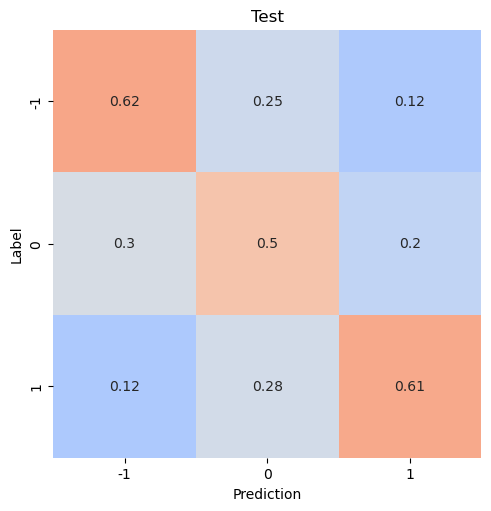

DG_Glut
zero: 5461, non-zero: 2849
213


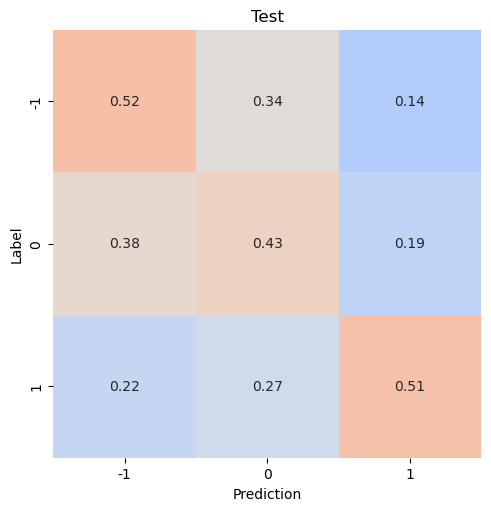

CA1-ProS_Glut
zero: 6930, non-zero: 1219
189


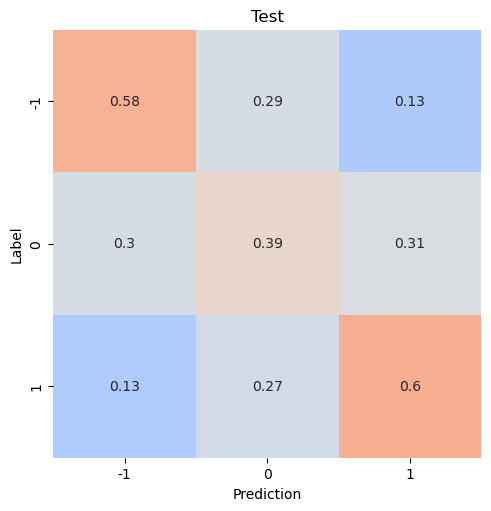

Oligo_NN
zero: 4009, non-zero: 1537
219


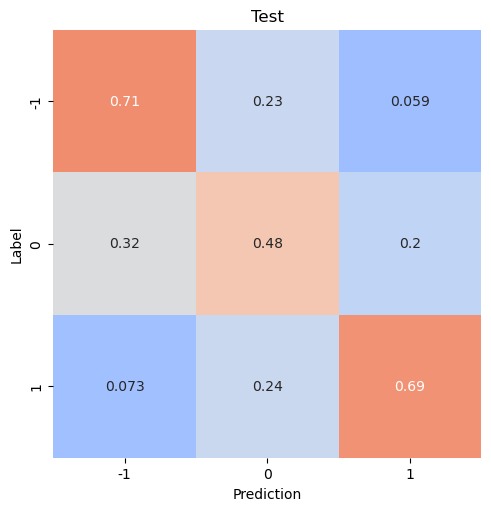

CA3_Glut
zero: 7816, non-zero: 861
179


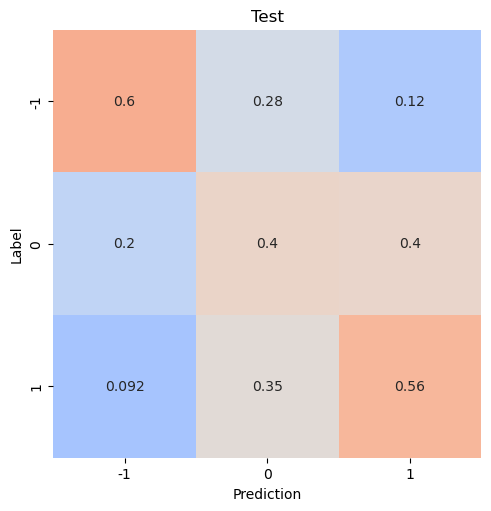

L6_CT_CTX_Glut
zero: 7885, non-zero: 1471
229


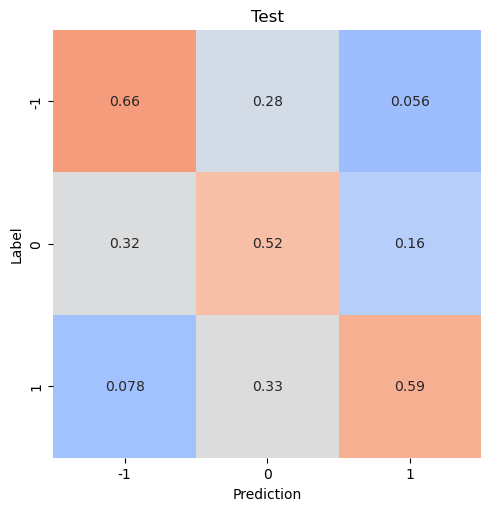

L6_IT_CTX_Glut
zero: 9063, non-zero: 190
205


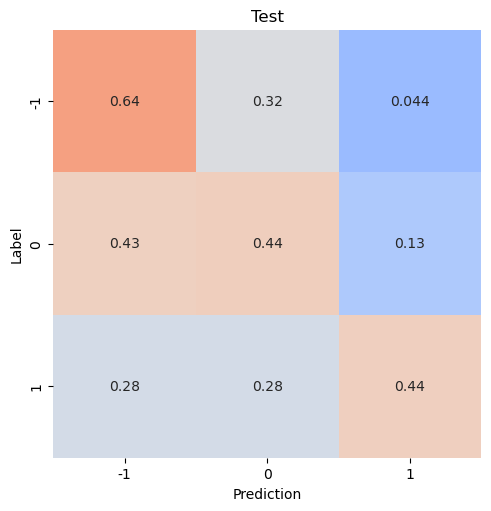

L5_ET_CTX_Glut
zero: 8692, non-zero: 491
195


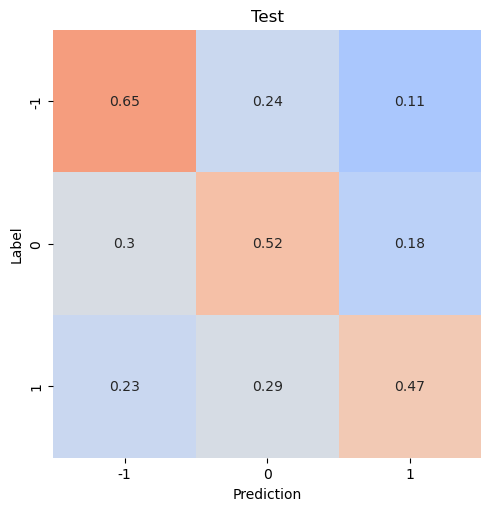

Astro-TE_NN
zero: 6436, non-zero: 193
251


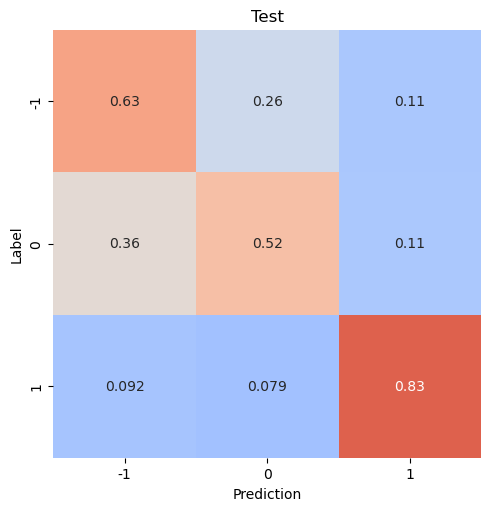

OPC_NN
zero: 6262, non-zero: 170
189


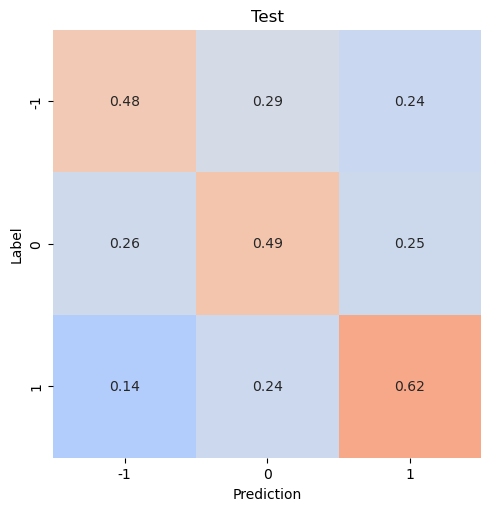

,acc,bal_acc,igr,micro_roc_auc,micro_AP
L23_IT_CTX_Glut,0.579295,0.575464,0.107117,0.775383,0.613897
DG_Glut,0.489118,0.486234,0.032892,0.706089,0.490827
CA1-ProS_Glut,0.522946,0.521610,0.102993,0.723831,0.577769
Oligo_NN,0.626898,0.625176,0.214151,0.812379,0.678823
CA3_Glut,0.510440,0.519260,0.092983,0.731931,0.541427
L6_CT_CTX_Glut,0.609243,0.589970,0.125374,0.804243,0.634476
L6_IT_CTX_Glut,0.550877,0.509680,0.116020,0.728778,0.550885
L5_ET_CTX_Glut,0.588371,0.549405,0.109387,0.774962,0.630352
Astro-TE_NN,0.647247,0.660029,0.282966,0.826566,0.706338
OPC_NN,0.541176,0.531017,0.131858,0.746713,0.620655


In [17]:
metrics_dict = {'acc' : [],  'bal_acc' : [], 'igr' : [], 'micro_roc_auc' : [], 'micro_AP' : []}
for _ct in cell_types: 
    print(_ct)

    X_balanced, y_balanced, FEATURE_TYPES = load_data_wrapper(_ct, DATA_FEATURE_NAMES,
                                                              y_val=p_y_val, _testing_type=p_testing_type, rna_type=p_rna_type, 
                                                             data_filepath = p_data_filepath, na_cutoff=p_na_cutoff)
            
    y_balanced += 1 # for 0, 1, 2, labels
    X = aggregate_modalities(X_balanced, FEATURE_TYPES)
    print(len(X.columns))
    
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_balanced)

    with open(f"../result_data/linear_baseline/model_metrics/{_ct}.best_params.csv", 'rb') as f: 
        params = pickle.load(f)
    
    
    metrics_inner = {'acc' : [],  'bal_acc' : [], 'igr' : [], 'micro_roc_auc' : [], 'micro_AP' : []}
    pred_list = []
    true_list = []

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=25)
    weights = []
    for i, (train_idx, test_idx) in enumerate(kf.split(X, y_balanced)): 
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y_balanced.iloc[train_idx]
        y_test = y_balanced.iloc[test_idx]

        scaler = StandardScaler()
        scaler = scaler.fit(X_train)
        X_scaled_train = scaler.transform(X_train)
        X_scaled_test = scaler.transform(X_test)
        
        sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        # sample_weights, sw_te = AK_sample_weights(y_train, y_test)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            clf = LogisticRegression(penalty=params['penalty'], solver=params['solver'], max_iter=params['max_iter'],
                                   tol=params['tol'], l1_ratio=params['l1_ratio'], random_state=params['random_state'])
            clf = clf.fit(X_scaled_train, y_train, sample_weight=sample_weights)
        weights.append(clf.coef_)
        
        # Getting some evaluation metrics
        y_pred = clf.predict(X_scaled_test)
        y_score = clf.predict_proba(X_scaled_test)
        max_gain = information_gain(y_test, y_test)
        gain_ratio = information_gain(y_test, y_pred) / max_gain
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)
        micro_roc_auc_ovr = roc_auc_score(y_test, y_score, multi_class="ovr", average="micro")
        prec, rec, micro_AP = micro_PRC(y_test, y_score)
    
        metrics_inner['igr'].append(gain_ratio)
        metrics_inner['bal_acc'].append(bal_acc)
        metrics_inner['acc'].append(acc)
        metrics_inner['micro_roc_auc'].append(micro_roc_auc_ovr)
        metrics_inner['micro_AP'].append(micro_AP)
        pred_list.extend(y_pred)
        true_list.extend(y_test)

    metrics_dict['igr'].append(np.mean(metrics_inner['igr']))
    metrics_dict['bal_acc'].append(np.mean(metrics_inner['bal_acc']))
    metrics_dict['acc'].append(np.mean(metrics_inner['acc']))
    metrics_dict['micro_roc_auc'].append(np.mean(metrics_inner['micro_roc_auc']))
    metrics_dict['micro_AP'].append(np.mean(metrics_inner['micro_AP']))                

    ccf_test = confusion_matrix(true_list, pred_list, normalize='true')
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
    sns.heatmap(ccf_test, vmin=0, vmax=1, center=0.33, xticklabels = ['-1', '0', '1'], yticklabels = ['-1', '0', '1'], 
                square=True, cmap='coolwarm', annot=True, cbar = False, ax=ax)
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Label")
    ax.set_title("Test")
    plt.show()

    # break 
    # Saving predictions
    df_pred = pd.DataFrame({"label": true_list, "pred":pred_list})
    df_pred.to_csv(f"../result_data/linear_baseline/model_metrics/{_ct}.preds.csv")
    
    # Saving some metrics 
    df_metrics = pd.DataFrame.from_dict(metrics_inner)
    df_metrics.to_csv(f"../result_data/linear_baseline/model_metrics/{_ct}.metrics.csv")

    # Saving model coefficients
    weights = np.asarray(weights)
    weights_list = []
    for i, wt_list in enumerate(weights): 
        df = pd.DataFrame(wt_list.T, columns=['down', 'non', 'up'], index=X.columns)
        df = df.reset_index(names="feature")
        df['cv'] = i
        # display(df)
        weights_list.append(df)
    df_weights = pd.concat(weights_list, axis=0)
    df_weights = df_weights.melt(id_vars = ['cv', 'feature'], var_name = "class", value_name = "weight")
    df_weights.to_csv(f"../result_data/linear_baseline/model_weights/{_ct}.weights.csv")
    
    # with open(f"../result_data/linear_baseline/model_weights/{_ct}.weights.pkl", 'wb') as f: 
    #     pickle.dump(weights, f)

df_metrics = pd.DataFrame.from_dict(metrics_dict, orient='index', columns=cell_types).T
df_metrics

### Old Search
This was essentially doing cv and then training a model on the whole set and predicting the whole set. The resulting models are what I would classif as the overfit models.

L23_IT_CTX_Glut
zero: 7789, non-zero: 1564
205


/gale/netapp/home2/aklein/miniconda3/envs/agp/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/gale/netapp/home2/aklein/miniconda3/envs/agp/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/gale/netapp/home2/aklein/miniconda3/envs/agp/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


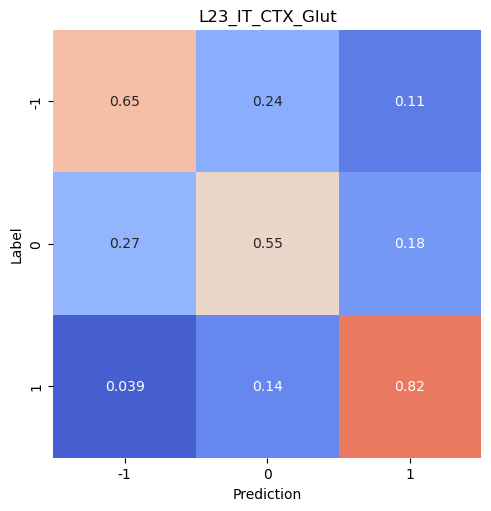

DG_Glut
zero: 5461, non-zero: 2849
213


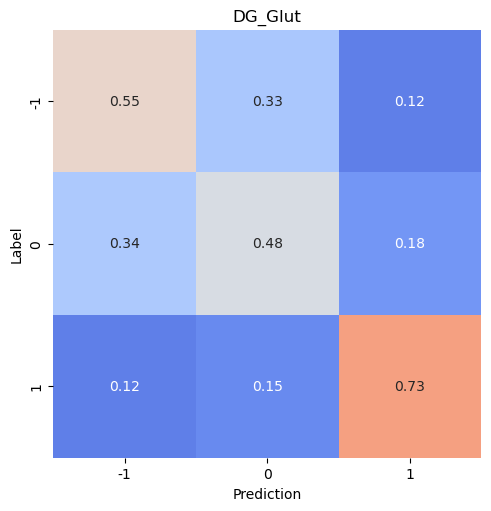

CA1-ProS_Glut
zero: 6930, non-zero: 1219
189


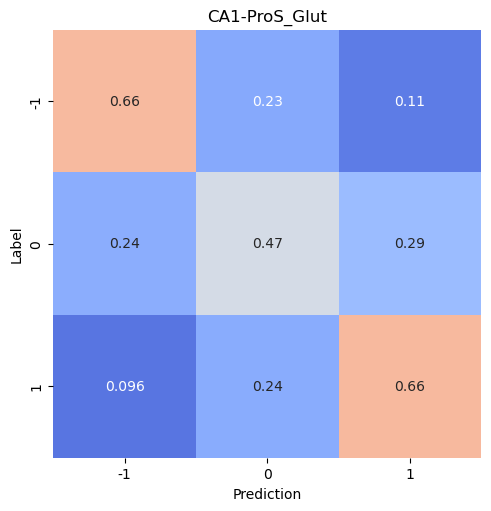

Oligo_NN
zero: 4009, non-zero: 1537
219


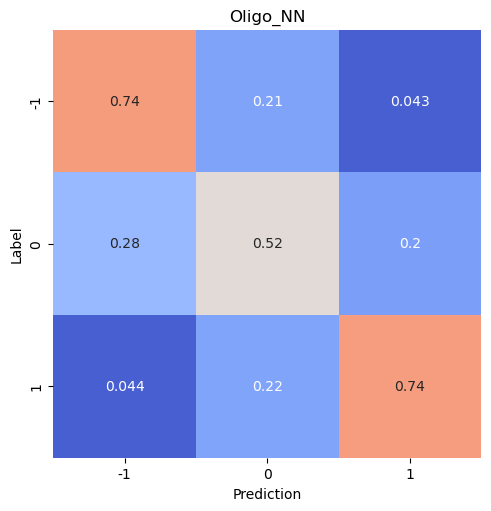

CA3_Glut
zero: 7816, non-zero: 861
179


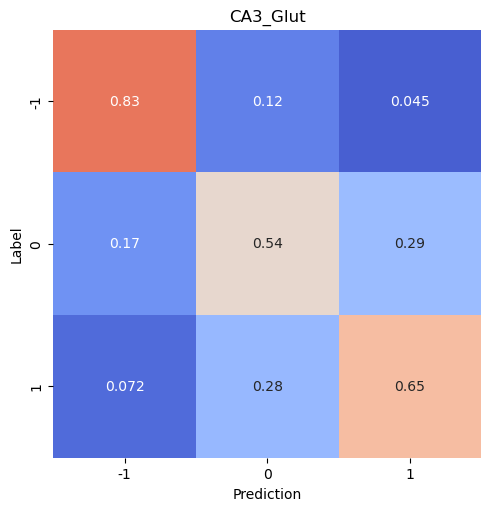

L6_CT_CTX_Glut
zero: 7885, non-zero: 1471
229


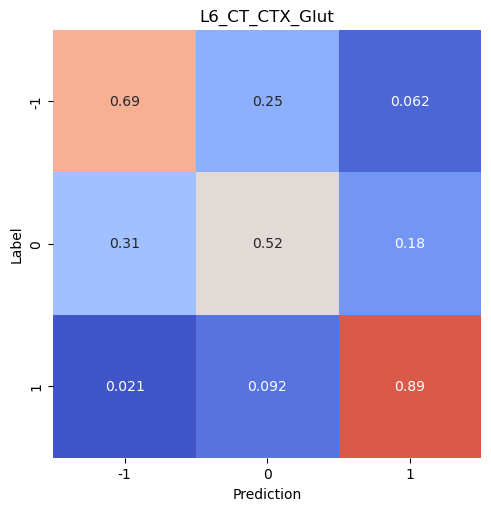

L6_IT_CTX_Glut
zero: 9063, non-zero: 190
205


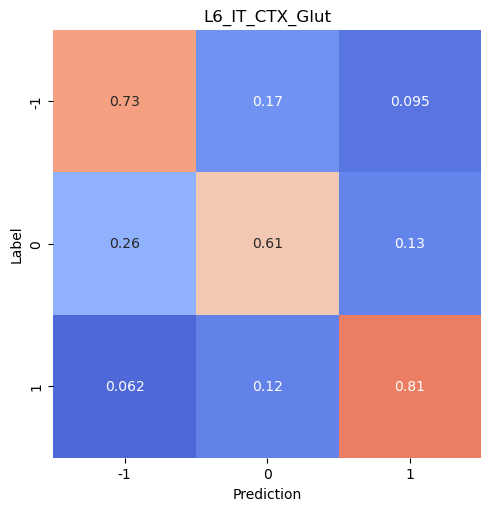

L5_ET_CTX_Glut
zero: 8692, non-zero: 491
195


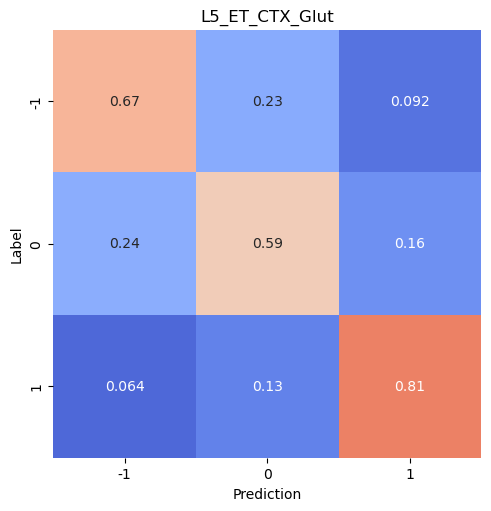

Astro-TE_NN
zero: 6436, non-zero: 193
251


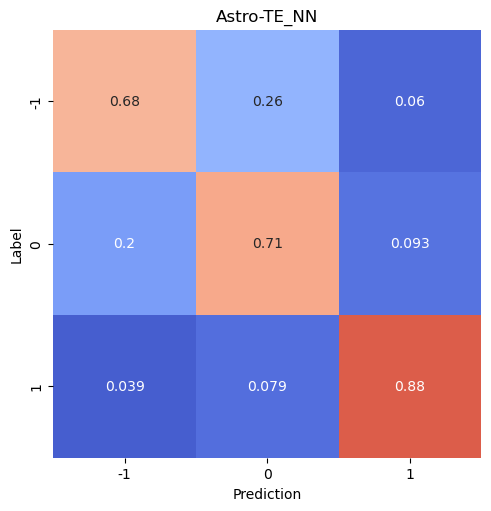

OPC_NN
zero: 6262, non-zero: 170
189


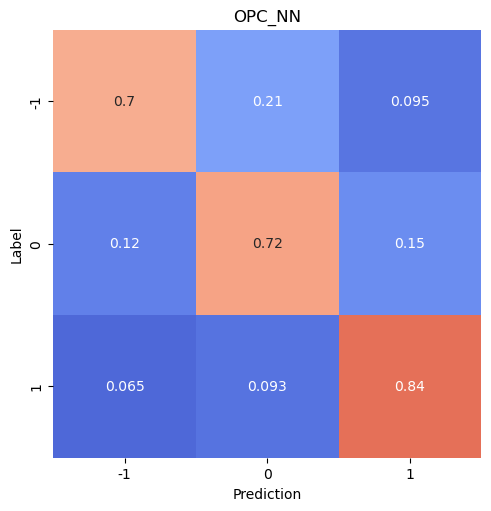

,acc,bal_acc,igr,micro_roc_auc,micro_AP
0,0.609974,0.673188,0.156404,0.798820,0.625489
1,0.519481,0.586115,0.058657,0.740560,0.528038
2,0.563167,0.595192,0.134278,0.760147,0.590402
3,0.629148,0.666402,0.223923,0.818190,0.659478
4,0.612079,0.674261,0.174580,0.811215,0.645304
5,0.613188,0.698004,0.166276,0.809463,0.633683
6,0.678947,0.719068,0.228804,0.836600,0.689555
7,0.644603,0.691840,0.189762,0.834695,0.702589
8,0.733161,0.755546,0.337779,0.893306,0.795991
9,0.755882,0.754355,0.341922,0.890588,0.810103


In [104]:
metrics_dict = {'acc' : [],  'bal_acc' : [], 'igr' : [], 'micro_roc_auc' : [], 'micro_AP' : []}
for _ct in cell_types: 
    print(_ct)

    X_balanced, y_balanced, FEATURE_TYPES = load_data_wrapper(_ct, DATA_FEATURE_NAMES,
                                                              y_val=p_y_val, _testing_type=p_testing_type, rna_type=p_rna_type, 
                                                             data_filepath = p_data_filepath, na_cutoff=p_na_cutoff)
            
    y_balanced += 1 # for 0, 1, 2, labels
    X = aggregate_modalities(X_balanced, FEATURE_TYPES)
    print(len(X.columns))
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    sample_weights = compute_sample_weight(class_weight="balanced", y=y_balanced)

    clf = LogisticRegressionCV(cv=5, penalty='elasticnet', solver='saga', max_iter=400, tol=6e-3, l1_ratios=np.arange(0, 1, .1),
                               random_state=13).fit(X_scaled, y_balanced, sample_weight=sample_weights)
    

    y_pred = clf.predict(X_scaled)
    y_score = clf.predict_proba(X_scaled)
    max_gain = information_gain(y_balanced, y_balanced)
    gain_ratio = information_gain(y_balanced, y_pred) / max_gain
    bal_acc = balanced_accuracy_score(y_balanced, y_pred)
    acc = accuracy_score(y_balanced, y_pred)
    micro_roc_auc_ovr = roc_auc_score(y_balanced, y_score, multi_class="ovr", average="micro")
    prec, rec, micro_AP = micro_PRC(y_balanced, y_score)

    metrics_dict['igr'].append(gain_ratio)
    metrics_dict['bal_acc'].append(bal_acc)
    metrics_dict['acc'].append(acc)
    metrics_dict['micro_roc_auc'].append(micro_roc_auc_ovr)
    metrics_dict['micro_AP'].append(micro_AP)
    
    ccf = confusion_matrix(y_balanced, y_pred, normalize='true')
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
    sns.heatmap(ccf, vmin=0, vmax=1, xticklabels = ['-1', '0', '1'], yticklabels = ['-1', '0', '1'], 
                square=True, cmap='coolwarm', annot=True, cbar = False, ax=ax)
    
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Label")
    ax.set_title(_ct)
    plt.show()
    
    df_pred = pd.DataFrame({"label": y_balanced, "pred":y_pred})
    df_pred.to_csv(f"../result_data/linear_baseline/model_metrics/{_ct}.overfit_preds.csv")
# break
df_metrics = pd.DataFrame.from_dict(metrics_dict)
df_metrics

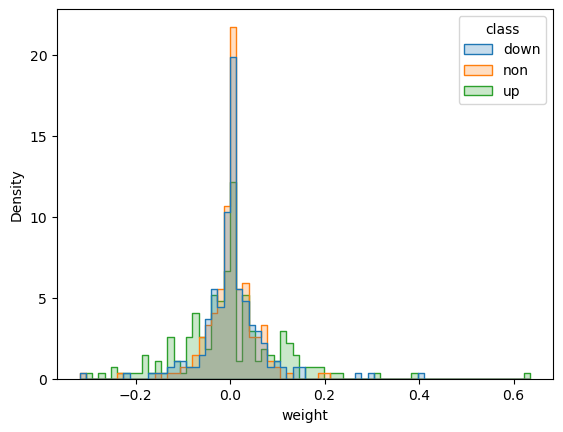

In [81]:
df_weights = pd.DataFrame(clf.coef_.T, columns=['down', 'non', 'up']).melt(var_name = "class", value_name = "weight")
sns.histplot(data=df_weights, x='weight', hue='class', common_norm=False, element='step', stat='density')
plt.show()